In [2]:
import bioframe as bf
import cooler
import cooltools
from joblib import Memory
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from scipy import stats
import os
import warnings
from sklearn.decomposition import PCA
from os import listdir
from statannotations.Annotator import Annotator

warnings.filterwarnings('ignore')


import matplotlib as mpl

mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('fontTools').setLevel(logging.WARNING)

# Merged maps

## Creation of compartments

In [3]:
res = 50_000


clr_names = {}

clr_dir = '../data/'

for file in listdir(clr_dir):
    if 'drop_diag.1kb.mcool' in file and 'merge' in file:
        name = file.split('.')[0]
        clr_names[name] = f"{clr_dir}/{file}"

clrs = {name: cooler.Cooler(clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}
clrs


{'SZ_minus_merge': <Cooler "SZ_minus_merge.sampled.drop_diag.1kb.mcool::/resolutions/50000">,
 'HC_plus_merge': <Cooler "HC_plus_merge.sampled.drop_diag.1kb.mcool::/resolutions/50000">,
 'SZ_plus_merge': <Cooler "SZ_plus_merge.sampled.drop_diag.1kb.mcool::/resolutions/50000">,
 'HC_minus_merge': <Cooler "HC_minus_merge.sampled.drop_diag.1kb.mcool::/resolutions/50000">}

In [7]:
bins = clrs[list(clr_names.keys())[0]].bins()[:]
hg38_genome = bf.load_fasta('../data/inspectro-master/hg38.fa');

gc_cov = bf.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_50kb.tsv',index=False,sep='\t')

In [ ]:
gc_cov = pd.read_csv('hg38_gc_cov_50kb.tsv', sep = '\t')

for name in list(clrs.keys()):
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    
    try:
        os.mkdir(f'schizo_12samples_merge_50k_resolution_results/{name}')
    except:
        print('Папка уже есть')
    
        
    n_eigv = 5
    
    chrom_arm = [123400000,93900000,90900000,50000000,48800000,59800000,60100000,45200000,43000000,39800000,53400000,35500000,17700000,17200000,19000000,36800000,25100000,18500000,26200000,28100000,12000000,15000000]

    for i in range(1, 23):
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': 0,
                            'end': chrom_arm[i-1],
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
            
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': chrom_arm[i-1],
                            'end': int(clr.chromsizes['chr' + str(i)]),
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
      


In [ ]:
for name in list(clrs.keys()):
    
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    clusters = pd.read_csv(f"../data/inspectro-master/results_scz_50kb/{name}.50000.E1-E5.kmeans_sm.tsv", sep = '\t')
    clusters = clusters[['chrom', 'start', 'end', 'kmeans_sm16']]
    clusters['kmeans_sm16'] = clusters['kmeans_sm16'].replace(16, np.nan)

    indexs = []
    n_eigv = 5
    
    for i in range(1, 23):
        if i not in [13, 14, 15, 21, 22]:
            cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['end'] <= chrom_arm[i-1])]['kmeans_sm16'])
            cis_eigs = np.zeros(n_eigv)
            
            for j in range(1, n_eigv+1):
                q = np.array(pd.read_csv(f'schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', header = None)[3])
                d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()
                cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

            indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))
            
        else:
            indexs.append(1)
            
        cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['start'] >= chrom_arm[i-1])]['kmeans_sm16'])
        cis_eigs = np.zeros(n_eigv)
        
        for j in range(1, n_eigv+1):
            q = np.array(pd.read_csv(f'schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', header = None)[3])
            d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()            
            cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

        indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))

    a = 'cat ' + ' '.join([f'schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_1_e{indexs[2*(i-1)]}.bed schizo_12samples_merge_50k_resolution_results/{s}_chr{i}_2_e{indexs[2*(i-1) + 1]}.bed' for i in range(1, 23)]) + f' > schizo_12samples_merge_50k_resolution_results/{s}_inspectro16_frankenstein_compartments.bed'
    os.system(f'{a}')



# NeuN plus

## Creation of compartments

In [ ]:
res = 100_000


clr_names = {}

clr_dir = '../data/'

for file in listdir(clr_dir):
    if 'drop_diag.1kb.mcool' in file and 'plus' in file and 'merge' not in file:
        name = file.split('.')[0]
        clr_names[name] = f"{clr_dir}/{file}"

clrs = {name: cooler.Cooler(clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}
clrs


In [ ]:
bins = clrs[list(clr_names.keys())[0]].bins()[:]
hg38_genome = bf.load_fasta('../data/nspectro-master/hg38.fa');

gc_cov = bf.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_100kb.tsv',index=False,sep='\t')

In [ ]:
gc_cov = pd.read_csv('hg38_gc_cov_100kb.tsv', sep = '\t')


for name in list(clrs.keys()):
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    
    try:
        os.mkdir(f'schizo_12samples_100k_resolution_results/{name}')
    except:
        print('Папка уже есть')
    
        
    n_eigv = 5
    
    chrom_arm = [123400000,93900000,90900000,50000000,48800000,59800000,60100000,45200000,43000000,39800000,53400000,35500000,17700000,17200000,19000000,36800000,25100000,18500000,26200000,28100000,12000000,15000000]

    for i in range(1, 23):
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': 0,
                            'end': chrom_arm[i-1],
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
            
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': chrom_arm[i-1],
                            'end': int(clr.chromsizes['chr' + str(i)]),
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
      


In [ ]:
for name in list(clrs.keys()):
    
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    clusters = pd.read_csv(f"../data/inspectro-master/results_scz_100kb/{name}.100000.E1-E5.kmeans_sm.tsv", sep = '\t')
    clusters = clusters[['chrom', 'start', 'end', 'kmeans_sm16']]
    clusters['kmeans_sm16'] = clusters['kmeans_sm16'].replace(16, np.nan)

    indexs = []
    n_eigv = 5
    
    for i in range(1, 23):
        if i not in [13, 14, 15, 21, 22]:
            cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['end'] <= chrom_arm[i-1])]['kmeans_sm16'])
            cis_eigs = np.zeros(n_eigv)
            
            for j in range(1, n_eigv+1):
                q = np.array(pd.read_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', header = None)[3])
                d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()
                cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

            indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))
            
        else:
            indexs.append(1)
            
        cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['start'] >= chrom_arm[i-1])]['kmeans_sm16'])
        cis_eigs = np.zeros(n_eigv)
        
        for j in range(1, n_eigv+1):
            q = np.array(pd.read_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', header = None)[3])
            d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()            
            cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

        indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))

    a = 'cat ' + ' '.join([f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{indexs[2*(i-1)]}.bed schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{indexs[2*(i-1) + 1]}.bed' for i in range(1, 23)]) + f' > schizo_12samples_100k_resolution_results/{s}_inspectro16_frankenstein_compartments.bed'
    os.system(f'{a}')



## Correlations

<Axes: >

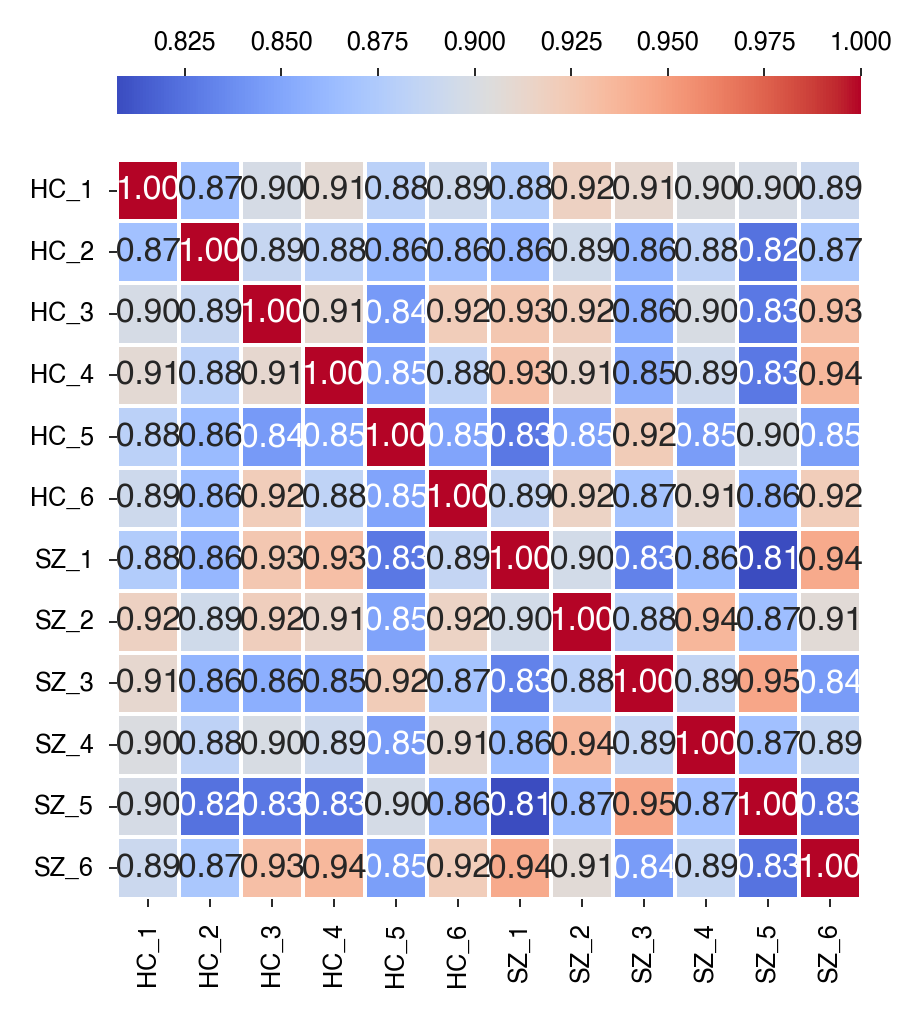

In [2]:
res = 100_000
plt.figure(dpi=300, figsize=(3.2, 4))
clr_names = {}

clr_dir = '../data/'

for file in listdir(clr_dir):
    if 'drop_diag.1kb.mcool' in file and 'plus' in file and 'merge' not in file:
        name = file.split('.')[0]
        clr_names[name] = f"{clr_dir}/{file}"

clrs = {name: cooler.Cooler(clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}

res = np.array([])
a = np.array([np.array(pd.read_csv('schizo_12samples_100k_resolution_results/' + name + '/' + name + '_inspectro16_frankenstein_compartments.bed', sep = '\t', names= ['chr', 'start', 'end', 'comp'])['comp']) for name in clrs.keys()]).T
a = pd.DataFrame(a, columns = clrs.keys())
a = a[~np.isnan(a).any(axis=1)]

samples_all_mapping = {'HC-2Mplus': 'HC_1',
 'HC-318plus': 'HC_2',
 'HC-3Mplus': 'HC_3',
 'HC-91plus': 'HC_4',
 'HC24plus': 'HC_5',
 'HCM12plus': 'HC_6',
 'SZ-01plus': 'SZ_1',
 'SZ-03plus': 'SZ_2',
 'SZ08plus': 'SZ_3',
 'SZ10plus': 'SZ_4',
 'SZ20plus': 'SZ_5',
 'SZ6plus': 'SZ_6'}

new_col_order = ['HC_1', 'HC_2', 'HC_3', 'HC_4', 'HC_5', 'HC_6', 
                 'SZ_1', 'SZ_2', 'SZ_3', 'SZ_4', 'SZ_5', 'SZ_6']


с = a.rename(columns = samples_all_mapping)
с = с[new_col_order]

col_name = {'HCM12plus': 'HCM12plus_35', 'SZ6plus': 'SZ6plus_62', 'HC-2Mplus':'HC-2Mplus_62', 'SZ08plus':'SZ08plus_56', 'HC-3Mplus':'HC-3Mplus_36', 'SZ20plus':'SZ20plus_45', 'HC24plus': 'HC24plus_54', 'SZ10plus': 'SZ10plus_50', 'HC-318plus': 'HC-318plus_58', 'SZ-01plus': 'SZ-01plus_36', 'SZ-03plus': 'SZ-03plus_57', 'HC-91plus': 'HC-91plus_59'}

a = a.rename(columns = col_name)
new_col_order = ['HCM12plus_35', 'HC-3Mplus_36', 'HC24plus_54', 'HC-318plus_58', 'HC-91plus_59', 'HC-2Mplus_62', 
                 'SZ-01plus_36', 'SZ20plus_45', 'SZ10plus_50', 'SZ08plus_56', 'SZ-03plus_57', 'SZ6plus_62']

a = a[new_col_order]
b = a.corr(method='pearson')
d = с.corr(method='pearson')


sns.heatmap(d, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws=dict(use_gridspec=False, location="top"))

#plt.savefig('picture_results/Compartment_correlation_heatmap_neuron.svg')
    

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Within
 HC vs. Within
 SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:8.357e-01 U_stat=1.180e+02
Within
 SZ vs. Between
 HC-SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:6.125e-01 U_stat=2.450e+02
Within
 HC vs. Between
 HC-SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:5.017e-01 U_stat=2.370e+02


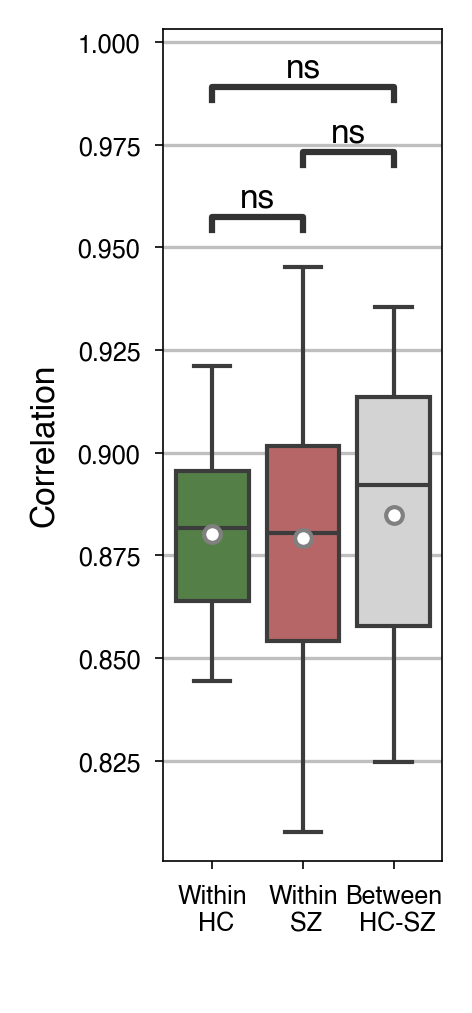

In [3]:
hc_col = ['HCM12plus_35', 'HC-3Mplus_36', 'HC24plus_54', 'HC-318plus_58', 'HC-91plus_59', 'HC-2Mplus_62']
sz_col = ['SZ-01plus_36', 'SZ20plus_45', 'SZ10plus_50', 'SZ08plus_56', 'SZ-03plus_57', 'SZ6plus_62']

hc_cor = b[hc_col]
hc_cor = hc_cor.iloc[hc_cor.index.isin(hc_col)]
hc_cor_num = hc_cor.values.flatten().tolist()
hc_cor_num = list(set(hc_cor_num))
hc_cor_num.remove(float(1))

hcsz_cor = b[hc_col]
hcsz_cor = hcsz_cor.iloc[hcsz_cor.index.isin(sz_col)]
hcsz_cor_num = hcsz_cor.values.flatten().tolist()

sz_cor = b[sz_col]
sz_cor = sz_cor.iloc[sz_cor.index.isin(sz_col)]
sz_cor_num = sz_cor.values.flatten().tolist()
sz_cor_num = list(set(sz_cor_num))
sz_cor_num.remove(float(1))

colormap = {'Within\n HC': '#4e893f', 
            'Within\n SZ': '#c35959',
            'Between\n HC-SZ': '#d3d3d3'}

df = pd.DataFrame({'Correlation': hc_cor_num + sz_cor_num + hcsz_cor_num, ' ': ['Within\n HC' for _ in range(len(hc_cor_num))] + ['Within\n SZ' for _ in range(len(sz_cor_num))] + ['Between\n HC-SZ' for _ in range(len(hcsz_cor_num))]})

plt.figure(dpi=300, figsize=(1.2,3.6))
box_plot=sns.boxplot(data = df, y = 'Correlation', x = ' ', showfliers=False, palette = colormap, showmeans=True,
                     meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"grey",
                       "markersize":"4", 'linewidth' : 0.1})
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('Within\n HC', 'Within\n SZ'), ('Within\n HC', 'Between\n HC-SZ'), ('Between\n HC-SZ', 'Within\n SZ')]

annotator = Annotator(box_plot, pairs, data=df, y = 'Correlation', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.savefig('picture_results/Compartment_correlation_boxplot_neuron.svg',bbox_inches='tight')

# NeuN minus

## Creation of compartments

In [ ]:
res = 100_000


clr_names = {}

clr_dir = '../data/'

for file in listdir(clr_dir):
    if 'drop_diag.1kb.mcool' in file and 'minus' in file and 'merge' not in file:
        name = file.split('.')[0]
        clr_names[name] = f"{clr_dir}/{file}"

clrs = {name: cooler.Cooler(clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}
clrs


In [ ]:
gc_cov = pd.read_csv('hg38_gc_cov_100kb.tsv', sep = '\t')


#for name in list(clrs.keys()):
for name in list(clrs.keys()):
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    
    try:
        os.mkdir(f'schizo_12samples_100k_resolution_results/{name}')
    except:
        print('Папка уже есть')
    
        
    n_eigv = 5
    
    chrom_arm = [123400000,93900000,90900000,50000000,48800000,59800000,60100000,45200000,43000000,39800000,53400000,35500000,17700000,17200000,19000000,36800000,25100000,18500000,26200000,28100000,12000000,15000000]

    for i in range(1, 23):
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': 0,
                            'end': chrom_arm[i-1],
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
            
        view_df = pd.DataFrame({'chrom': ['chr' + str(i)],
                            'start': chrom_arm[i-1],
                            'end': int(clr.chromsizes['chr' + str(i)]),
                            'name': 'chr' + str(i)})
        cis_eigs = cooltools.eigs_cis(
                            clr,
                            gc_cov,
                            view_df=view_df,
                            n_eigs=n_eigv,)
        for j in range(1, n_eigv+1):
            cis_eigs[1][['chrom','start','end','E' + str(j)]].to_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', index=False, header = False, na_rep='NaN')
      


In [ ]:
for name in list(clrs.keys()):
    
    clr = clrs[name]
    s = f'{name}/{name}'
    print(name)
    clusters = pd.read_csv(f"../data/inspectro-master/results_scz_100kb/{name}.100000.E1-E5.kmeans_sm.tsv", sep = '\t')
    clusters = clusters[['chrom', 'start', 'end', 'kmeans_sm16']]
    clusters['kmeans_sm16'] = clusters['kmeans_sm16'].replace(16, np.nan)

    indexs = []
    n_eigv = 5
    
    for i in range(1, 23):
        if i not in [13, 14, 15, 21, 22]:
            cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['end'] <= chrom_arm[i-1])]['kmeans_sm16'])
            cis_eigs = np.zeros(n_eigv)
            
            for j in range(1, n_eigv+1):
                q = np.array(pd.read_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{j}.bed', sep = '\t', header = None)[3])
                d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()
                cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

            indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))
            
        else:
            indexs.append(1)
            
        cl = np.array(clusters.loc[(clusters['chrom'] == 'chr' + str(i))&(clusters['start'] >= chrom_arm[i-1])]['kmeans_sm16'])
        cis_eigs = np.zeros(n_eigv)
        
        for j in range(1, n_eigv+1):
            q = np.array(pd.read_csv(f'schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{j}.bed', sep = '\t', header = None)[3])
            d = pd.DataFrame({1:cl, 2:q}).replace([np.inf, -np.inf], np.nan).dropna()            
            cis_eigs[j-1] = stats.pearsonr(d[1].astype(np.float64), d[2].astype(np.float64))[0]

        indexs.append(int(np.where(cis_eigs == max(cis_eigs))[0] + 1))

    a = 'cat ' + ' '.join([f'schizo_12samples_100k_resolution_results/{s}_chr{i}_1_e{indexs[2*(i-1)]}.bed schizo_12samples_100k_resolution_results/{s}_chr{i}_2_e{indexs[2*(i-1) + 1]}.bed' for i in range(1, 23)]) + f' > schizo_12samples_100k_resolution_results/{s}_inspectro16_frankenstein_compartments.bed'
    os.system(f'{a}')



## Correlations

<Axes: >

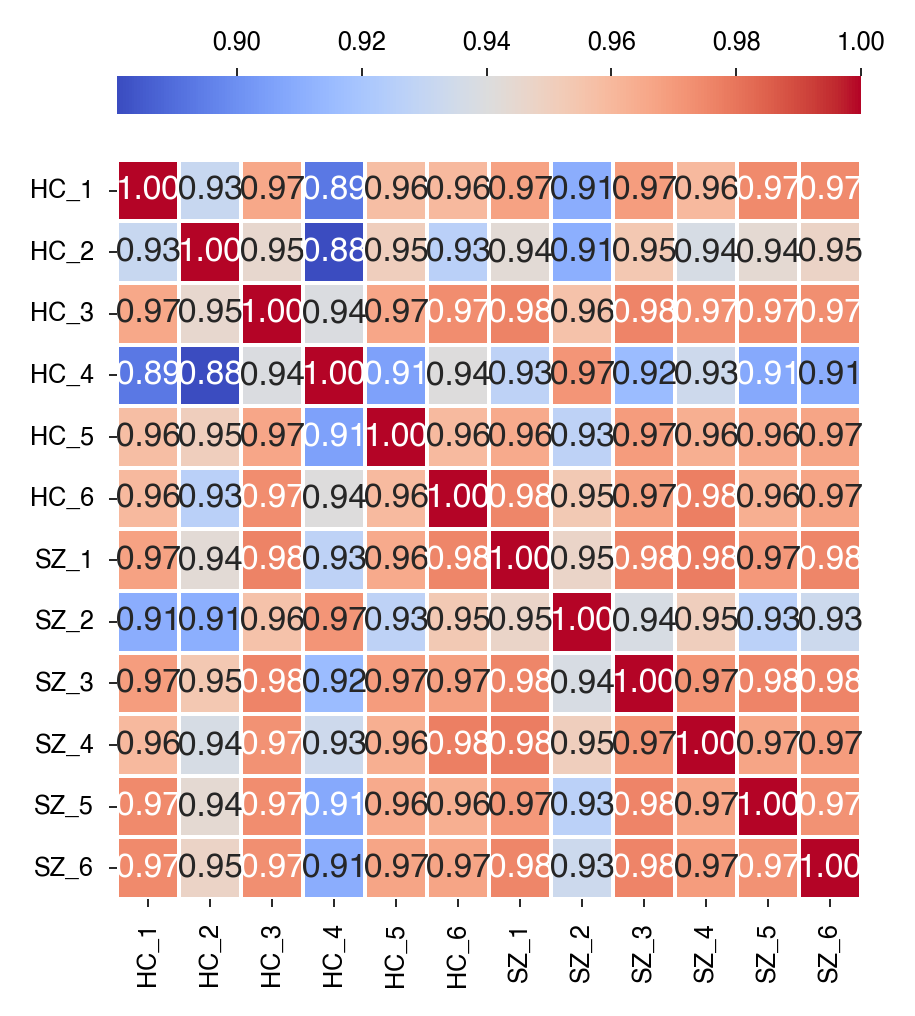

In [4]:
res = 100_000
plt.figure(dpi=300, figsize=(3.2, 4))
clr_names = {}

clr_names = {}

clr_dir = '../data/'

for file in listdir(clr_dir):
    if 'drop_diag.1kb.mcool' in file and 'minus' in file and 'merge' not in file:
        name = file.split('.')[0]
        clr_names[name] = f"{clr_dir}/{file}"

clrs = {name: cooler.Cooler(clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}
clrs

res = np.array([])


a = np.array([np.array(pd.read_csv('schizo_12samples_100k_resolution_results/' + name + '/' + name + '_inspectro16_frankenstein_compartments.bed', sep = '\t', names= ['chr', 'start', 'end', 'comp'])['comp']) for name in clrs.keys()]).T
a = pd.DataFrame(a, columns = clrs.keys())
a = a[~np.isnan(a).any(axis=1)]

samples_all_mapping = {
 'HC-2Mminus': 'HC_1',
 'HC-318minus': 'HC_2',
 'HC-3Mminus': 'HC_3',
 'HC-91minus': 'HC_4',
 'HC24minus': 'HC_5',
 'HCM12minus': 'HC_6',
 'SZ-01minus': 'SZ_1',
 'SZ-03minus': 'SZ_2',
 'SZ08minus': 'SZ_3',
 'SZ10minus': 'SZ_4',
 'SZ20minus': 'SZ_5',
 'SZ6minus': 'SZ_6'}

new_col_order = ['HC_1', 'HC_2', 'HC_3', 'HC_4', 'HC_5', 'HC_6', 
                 'SZ_1', 'SZ_2', 'SZ_3', 'SZ_4', 'SZ_5', 'SZ_6']

с = a.rename(columns = samples_all_mapping)
с = с[new_col_order]

col_name = {'HCM12minus': 'HCM12minus_35', 'SZ6minus': 'SZ6minus_62', 'HC-2Mminus':'HC-2Mminus_62', 'SZ08minus':'SZ08minus_56', 'HC-3Mminus':'HC-3Mminus_36', 'SZ20minus':'SZ20minus_45', 'HC24minus': 'HC24minus_54', 'SZ10minus': 'SZ10minus_50', 'HC-318minus': 'HC-318minus_58', 'SZ-01minus': 'SZ-01minus_36', 'SZ-03minus': 'SZ-03minus_57', 'HC-91minus': 'HC-91minus_59'}
a = a.rename(columns = col_name)
new_col_order = ['HCM12minus_35', 'HC-3Mminus_36', 'HC24minus_54', 'HC-318minus_58', 'HC-91minus_59', 'HC-2Mminus_62', 
                 'SZ-01minus_36', 'SZ20minus_45', 'SZ10minus_50', 'SZ08minus_56', 'SZ-03minus_57', 'SZ6minus_62']

a = a[new_col_order]
b = a.corr(method='pearson')
d = с.corr(method='pearson')

sns.heatmap(d, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws=dict(use_gridspec=False, location="top"))

#plt.savefig('picture_results/Compartment_correlation_heatmap_glia.svg')







p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Within
 HC vs. Within
 SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:1.012e-02 U_stat=5.000e+01
Within
 SZ vs. Between
 HC-SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:1.629e-01 U_stat=3.380e+02
Within
 HC vs. Between
 HC-SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:3.588e-02 U_stat=1.680e+02


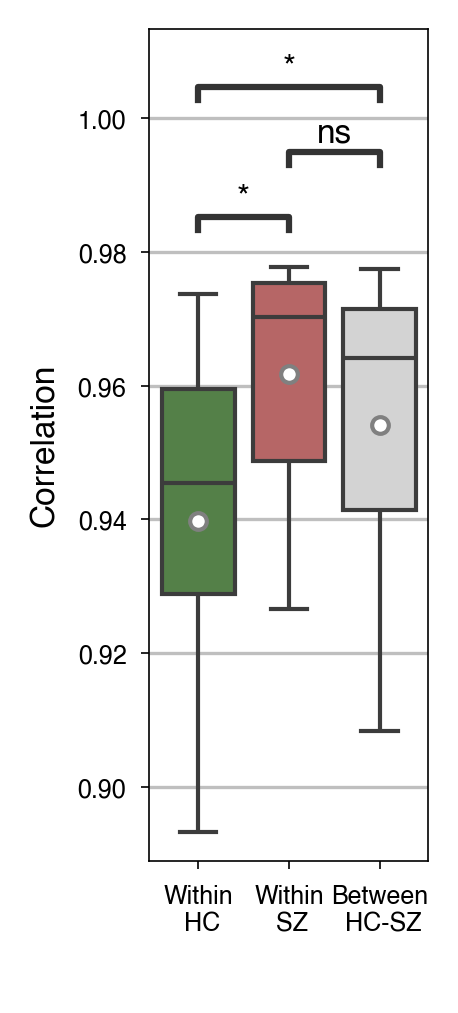

In [5]:


hc_col = ['HCM12minus_35', 'HC-3Mminus_36', 'HC24minus_54', 'HC-318minus_58', 'HC-91minus_59', 'HC-2Mminus_62']
sz_col = ['SZ-01minus_36', 'SZ20minus_45', 'SZ10minus_50', 'SZ08minus_56', 'SZ-03minus_57', 'SZ6minus_62']

hc_cor = b[hc_col]
hc_cor = hc_cor.iloc[hc_cor.index.isin(hc_col)]
hc_cor_num = hc_cor.values.flatten().tolist()
hc_cor_num = list(set(hc_cor_num))
hc_cor_num.remove(float(1))

hcsz_cor = b[hc_col]
hcsz_cor = hcsz_cor.iloc[hcsz_cor.index.isin(sz_col)]
hcsz_cor_num = hcsz_cor.values.flatten().tolist()

sz_cor = b[sz_col]
sz_cor = sz_cor.iloc[sz_cor.index.isin(sz_col)]
sz_cor_num = sz_cor.values.flatten().tolist()
sz_cor_num = list(set(sz_cor_num))
sz_cor_num.remove(float(1))

colormap = {'Within\n HC': '#4e893f', 
            'Within\n SZ': '#c35959',
            'Between\n HC-SZ': '#d3d3d3'}

df = pd.DataFrame({'Correlation': hc_cor_num + sz_cor_num + hcsz_cor_num, ' ': ['Within\n HC' for _ in range(len(hc_cor_num))] + ['Within\n SZ' for _ in range(len(sz_cor_num))] + ['Between\n HC-SZ' for _ in range(len(hcsz_cor_num))]})

plt.figure(dpi=300, figsize=(1.2,3.6))
box_plot=sns.boxplot(data = df, y = 'Correlation', x = ' ', showfliers=False, palette = colormap, showmeans=True,
                     meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"grey",
                       "markersize":"4", 'linewidth' : 0.1})
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)
pairs = [('Within\n HC', 'Within\n SZ'), ('Within\n HC', 'Between\n HC-SZ'), ('Between\n HC-SZ', 'Within\n SZ')]

annotator = Annotator(box_plot, pairs, data=df, y = 'Correlation', x = ' ')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.tight_layout()
plt.savefig('picture_results/Compartment_correlation_boxplot_glia.svg',bbox_inches='tight')